# Library Imports

In [ ]:
!pip install transformers

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 48.2 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from wordcloud import WordCloud

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Conv1D, MaxPool1D
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Exploring Fake News

In [ ]:
import pandas as pd

file_path = "/content/drive/My Drive/Aurangzaib/dataset/Fake.csv"
fake = pd.read_csv(file_path)

In [ ]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
for key,count in fake.subject.value_counts().items():
    print(f"{key}:\t{count}")

print(f"Total Records:\t{fake.shape[0]}")

News:	9050
politics:	6841
left-news:	4459
Government News:	1570
US_News:	783
Middle-east:	778
Total Records:	23481


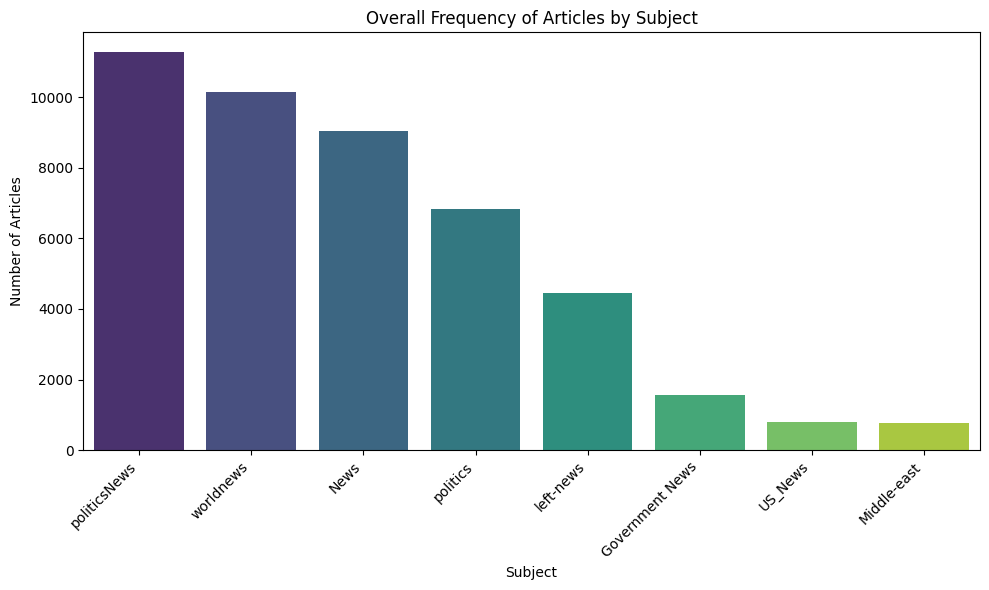

In [ ]:
# Ensure 'fake' and 'real' dataframes are loaded (if not already)
try:
    fake['subject']
    real['subject']
except NameError:
    fake_file_path = "/content/drive/My Drive/Aurangzaib/dataset/Fake.csv"
    fake = pd.read_csv(fake_file_path)
    real_file_path = "/content/drive/My Drive/Aurangzaib/dataset/True.csv"
    real = pd.read_csv(real_file_path)

# Combine the 'subject' columns from both dataframes
all_subjects = pd.concat([fake['subject'], real['subject']], ignore_index=True)

# Create a vertical bar plot of the overall frequency of subjects
plt.figure(figsize=(10, 6))
sns.countplot(x=all_subjects, order=all_subjects.value_counts().index, palette='viridis')
plt.title('Overall Frequency of Articles by Subject')
plt.xlabel('Subject')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

In [ ]:
'''text = ''
for news in fake.text.values:
    text += f" {news}"
wordcloud = WordCloud(
    width = 3000,
    height = 2000,
    background_color = 'black',
    stopwords = set(nltk.corpus.stopwords.words("english"))).generate(str(text))
fig = plt.figure(
    figsize = (40, 30),
    facecolor = 'k',
    edgecolor = 'k')
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()
del text'''

'text = \'\'\nfor news in fake.text.values:\n    text += f" {news}"\nwordcloud = WordCloud(\n    width = 3000,\n    height = 2000,\n    background_color = \'black\',\n    stopwords = set(nltk.corpus.stopwords.words("english"))).generate(str(text))\nfig = plt.figure(\n    figsize = (40, 30),\n    facecolor = \'k\',\n    edgecolor = \'k\')\nplt.imshow(wordcloud, interpolation = \'bilinear\')\nplt.axis(\'off\')\nplt.tight_layout(pad=0)\nplt.show()\ndel text'

In [ ]:
import pandas as pd

file_path = "/content/drive/My Drive/Aurangzaib/dataset/True.csv"
real = pd.read_csv(file_path)
real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
unknown_publishers = []
for index,row in enumerate(real.text.values):
    try:
        record = row.split(" -", maxsplit=1)
        record[1]
        assert(len(record[0]) < 260)
    except:
        unknown_publishers.append(index)

In [ ]:
real.iloc[unknown_publishers].text

,text
3488,The White House on Wednesday disclosed a group...
4358,"Neil Gorsuch, President Donald Trump’s appoint..."
4465,WASHINGTON The clock began running out this we...
5784,"Federal appeals court judge Neil Gorsuch, the ..."
6660,Republican members of Congress are complaining...
6823,Over the course of the U.S. presidential campa...
7922,After going through a week reminiscent of Napo...
8194,The following timeline charts the origin and s...
8195,Global health officials are racing to better u...
8247,U.S. President Barack Obama visited a street m...


In [ ]:
real.iloc[8970]

,8970
title,Graphic: Supreme Court roundup
text,
subject,politicsNews
date,"June 16, 2016"


In [ ]:
publisher = []
tmp_text = []
for index,row in enumerate(real.text.values):
    if index in unknown_publishers:
        tmp_text.append(row)

        publisher.append("Unknown")
        continue
    record = row.split(" -", maxsplit=1)
    publisher.append(record[0])
    tmp_text.append(record[1])

In [ ]:
real["publisher"] = publisher
real["text"] = tmp_text

del publisher, tmp_text, record, unknown_publishers

In [ ]:
real.head()

,title,text,subject,date,publisher
0,"As U.S. budget fight looms, Republicans flip t...",The head of a conservative Republican faction...,politicsNews,"December 31, 2017",WASHINGTON (Reuters)
1,U.S. military to accept transgender recruits o...,Transgender people will be allowed for the fi...,politicsNews,"December 29, 2017",WASHINGTON (Reuters)
2,Senior U.S. Republican senator: 'Let Mr. Muell...,The special counsel investigation of links be...,politicsNews,"December 31, 2017",WASHINGTON (Reuters)
3,FBI Russia probe helped by Australian diplomat...,Trump campaign adviser George Papadopoulos to...,politicsNews,"December 30, 2017",WASHINGTON (Reuters)
4,Trump wants Postal Service to charge 'much mor...,President Donald Trump called on the U.S. Pos...,politicsNews,"December 29, 2017",SEATTLE/WASHINGTON (Reuters)


In [ ]:
[index for index,text in enumerate(real.text.values) if str(text).strip() == '']

[8970]

In [ ]:
if 8970 in real.index:
    real = real.drop(8970, axis=0)
else:
    print("Index 8970 not found in DataFrame.")

In [ ]:
empty_fake_index = [index for index,text in enumerate(fake.text.values) if str(text).strip() == '']
print(f"No of empty rows: {len(empty_fake_index)}")
fake.iloc[empty_fake_index].tail()

No of empty rows: 630


,title,text,subject,date
21816,BALTIMORE BURNS: MARYLAND GOVERNOR BRINGS IN N...,,left-news,"Apr 27, 2015"
21826,FULL VIDEO: THE BLOCKBUSTER INVESTIGATION INTO...,,left-news,"Apr 25, 2015"
21827,(VIDEO) HILLARY CLINTON: RELIGIOUS BELIEFS MUS...,,left-news,"Apr 25, 2015"
21857,(VIDEO)ICE PROTECTING OBAMA: WON’T RELEASE NAM...,,left-news,"Apr 14, 2015"
21873,(VIDEO) HYSTERICAL SNL TAKE ON HILLARY’S ANNOU...,,left-news,"Apr 12, 2015"


In [ ]:
print(f"Total Records:\t{real.shape[0]}")

for key,count in real.subject.value_counts().items():
  print(f"{key}:\t{count}")

Total Records:	21416
politicsNews:	11271
worldnews:	10145


In [ ]:
'''text = ''
for news in real.text.values:
    text += f" {news}"
wordcloud = WordCloud(
    width = 3000,
    height = 2000,
    background_color = 'black',
    stopwords = set(nltk.corpus.stopwords.words("english"))).generate(str(text))
fig = plt.figure(
    figsize = (40, 30),
    facecolor = 'k',
    edgecolor = 'k')
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()
del text'''

'text = \'\'\nfor news in real.text.values:\n    text += f" {news}"\nwordcloud = WordCloud(\n    width = 3000,\n    height = 2000,\n    background_color = \'black\',\n    stopwords = set(nltk.corpus.stopwords.words("english"))).generate(str(text))\nfig = plt.figure(\n    figsize = (40, 30),\n    facecolor = \'k\',\n    edgecolor = \'k\')\nplt.imshow(wordcloud, interpolation = \'bilinear\')\nplt.axis(\'off\')\nplt.tight_layout(pad=0)\nplt.show()\ndel text'

# Preprocessing Text

In [ ]:
real["class"] = 1
fake["class"] = 0

In [ ]:
real["text"] = real["title"] + " " + real["text"]
fake["text"] = fake["title"] + " " + fake["text"]

In [ ]:
real = real.drop(["subject", "date","title",  "publisher"], axis=1)
fake = fake.drop(["subject", "date", "title"], axis=1)

In [ ]:
if 'real' in locals() and 'fake' in locals():
    data = pd.concat([real, fake], ignore_index=True)
    del real, fake
else:
    print("Error: Both 'real' and 'fake' DataFrames must be loaded before concatenation.")

Removing StopWords, Punctuations and single-character words

In [ ]:
y = data["class"].values
X = []
stop_words = set(nltk.corpus.stopwords.words("english"))
tokenizer = nltk.tokenize.RegexpTokenizer(r'\w+')
for par in data["text"].values:
    tmp = []
    sentences = nltk.sent_tokenize(par)
    for sent in sentences:
        sent = sent.lower()
        tokens = tokenizer.tokenize(sent)
        filtered_words = [w.strip() for w in tokens if w not in stop_words and len(w) > 1]
        tmp.extend(filtered_words)
    X.append(tmp)

del data

In [ ]:
import gensim

In [ ]:
EMBEDDING_DIM = 100

w2v_model = gensim.models.Word2Vec(sentences=X, vector_size=EMBEDDING_DIM, window=5, min_count=1)

In [ ]:
len(w2v_model.wv.key_to_index)

122248

In [ ]:
w2v_model

In [ ]:
w2v_model.wv["corona"]

array([ 0.00047044,  0.00636344, -0.03254719,  0.02297649, -0.00027388,
       -0.06374265,  0.09405073,  0.12071924,  0.00438253, -0.1473372 ,
       -0.02205198, -0.03142281, -0.04498026, -0.07906755, -0.02094802,
       -0.03162365,  0.00794241, -0.05559481, -0.00425195, -0.00921743,
       -0.01821292,  0.03943075, -0.02729307, -0.04568811,  0.04331299,
       -0.00511994, -0.09811936,  0.01132686, -0.04009274, -0.01404055,
        0.00716198, -0.01066813, -0.02161766,  0.03199468, -0.00573467,
        0.03643844,  0.04238619, -0.0185702 , -0.03410568, -0.03715705,
        0.03977332,  0.04840039, -0.03274918, -0.02186015,  0.0424252 ,
        0.0200183 , -0.0757909 , -0.05535305,  0.01076979,  0.00806791,
        0.0312981 , -0.03472668, -0.02400358, -0.00577791, -0.06577841,
        0.02221116,  0.02962151, -0.00587838, -0.01910729,  0.02139209,
       -0.0465558 ,  0.03971555,  0.03176092,  0.02450731,  0.0043058 ,
       -0.01706753,  0.00565209,  0.02660286, -0.01378297,  0.00

In [ ]:
w2v_model.wv.most_similar("iran")

[('tehran', 0.8769484162330627),
 ('iranian', 0.7537844777107239),
 ('hezbollah', 0.6326260566711426),
 ('destabilizing', 0.623192310333252),
 ('iranians', 0.6063061356544495),
 ('riyadh', 0.6019055843353271),
 ('jcpoa', 0.6010783314704895),
 ('turkey', 0.5966757535934448),
 ('nuclear', 0.5899498462677002),
 ('russia', 0.5857679843902588)]

In [ ]:
w2v_model.wv.most_similar("fbi")

[('comey', 0.7142550945281982),
 ('investigators', 0.6379302740097046),
 ('investigation', 0.632815420627594),
 ('cia', 0.6246457695960999),
 ('doj', 0.6037737131118774),
 ('mueller', 0.5905590057373047),
 ('investigated', 0.5508436560630798),
 ('inquiry', 0.5467469096183777),
 ('investigations', 0.5429931282997131),
 ('probe', 0.5366150140762329)]

In [ ]:
w2v_model.wv.most_similar("facebook")

[('google', 0.6689633727073669),
 ('gofundme', 0.6649179458618164),
 ('fb', 0.6599723696708679),
 ('instagram', 0.6470286250114441),
 ('reddit', 0.6435096263885498),
 ('online', 0.5843797922134399),
 ('blog', 0.5822973847389221),
 ('llistaunitaria', 0.580158531665802),
 ('website', 0.5734725594520569),
 ('posting', 0.5574508905410767)]

In [ ]:
w2v_model.wv.most_similar("computer")

[('computers', 0.8270716667175293),
 ('software', 0.7775047421455383),
 ('malware', 0.7697878479957581),
 ('electronic', 0.7588996887207031),
 ('laptop', 0.753078818321228),
 ('encrypted', 0.7320569753646851),
 ('scanning', 0.7148988842964172),
 ('kaspersky', 0.7014630436897278),
 ('servers', 0.6950192451477051),
 ('detection', 0.6936636567115784)]

In [ ]:
w2v_model.wv.most_similar(positive=["trump","obama", "clinton"])


[('bush', 0.5361477732658386),
 ('elect', 0.5318469405174255),
 ('cruz', 0.5140397548675537),
 ('incoming', 0.5112511515617371),
 ('hillary', 0.500758171081543),
 ('americas_dad', 0.497466117143631),
 ('crooked', 0.48716628551483154),
 ('course', 0.4817534387111664),
 ('outright', 0.4592282474040985),
 ('bartlet', 0.45500245690345764)]

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X)

X = tokenizer.texts_to_sequences(X)

In [ ]:
X[0][:10]

[389, 395, 10495, 54, 5509, 1286, 4840, 315, 205, 16]

In [ ]:
word_index = tokenizer.word_index
for word, num in word_index.items():
    print(f"{word} -> {num}")
    if num == 10:
        break

trump -> 1
said -> 2
president -> 3
would -> 4
people -> 5
one -> 6
state -> 7
new -> 8
obama -> 9
also -> 10


In [ ]:
import numpy as np

nos = np.array([len(x) for x in X])
len(nos[nos  < 700])

43982

In [ ]:
maxlen = 700

X = pad_sequences(X, maxlen=maxlen)

In [ ]:
len(X[0])

700

In [ ]:
vocab_size = len(tokenizer.word_index) + 1

In [ ]:
def get_weight_matrix(model, vocab):
    vocab_size = len(vocab) + 1
    weight_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
    for word, i in vocab.items():
        weight_matrix[i] = model.wv[word]
    return weight_matrix

In [ ]:
embedding_vectors = get_weight_matrix(w2v_model, word_index)

In [ ]:
from tensorflow.keras.layers import Dropout

model = Sequential()
model.add(Embedding(vocab_size, output_dim=EMBEDDING_DIM, weights=[embedding_vectors], input_length=maxlen, trainable=False))
model.add(LSTM(units=128))
model.add(Dropout(0.5)) # Added Dropout layer with a rate of 0.5
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adamW', loss='binary_crossentropy', metrics=['acc'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │    12,224,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,224,900 (46.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 12,224,900 (46.63 MB)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
history = model.fit(X_train, y_train, validation_split=0.3, epochs=50)

Epoch 1/50
737/737 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - acc: 0.9299 - loss: 0.1842 - val_acc: 0.9721 - val_loss: 0.0866
Epoch 2/50
737/737 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - acc: 0.9680 - loss: 0.0958 - val_acc: 0.9731 - val_loss: 0.0839
Epoch 3/50
737/737 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - acc: 0.9729 - loss: 0.0805 - val_acc: 0.9713 - val_loss: 0.0887
Epoch 4/50
737/737 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - acc: 0.9807 - loss: 0.0600 - val_acc: 0.9810 - val_loss: 0.0579
Epoch 5/50
737/737 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - acc: 0.9883 - loss: 0.0331 - val_acc: 0.9881 - val_loss: 0.0346
Epoch 6/50
737/737 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - acc: 0.9930 - loss: 0.0200 - val_acc: 0.9886 - val_loss: 0.0348
Epoch 7/50
737/737 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - acc: 0.9925 - loss: 0.0229 - val_acc: 0.9898 - val_loss: 0.0308
Epoch 8/50
737/737 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - acc: 0.9954 - loss: 0.0134 - val_acc: 0.9900 - val_loss: 0.0299
Epoch 9/50
737/737 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
y_pred = (model.predict(X_test) >= 0.5).astype("int")

351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [ ]:
accuracy_score(y_test, y_pred)

0.9937639198218263

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5795
           1       0.99      0.99      0.99      5430

    accuracy                           0.99     11225
   macro avg       0.99      0.99      0.99     11225
weighted avg       0.99      0.99      0.99     11225



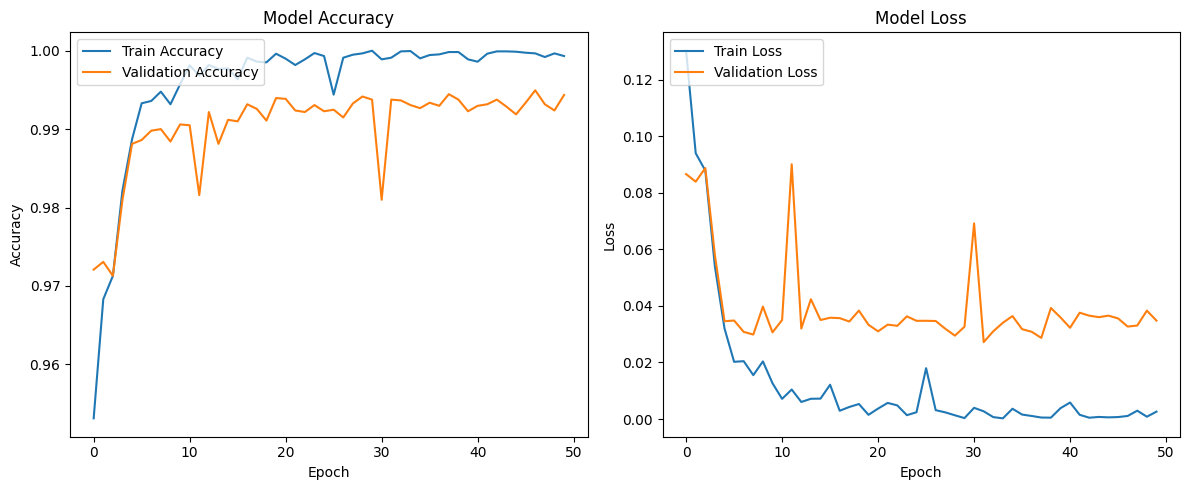

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['acc'], label='Train Accuracy')
plt.plot(history.history['val_acc'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


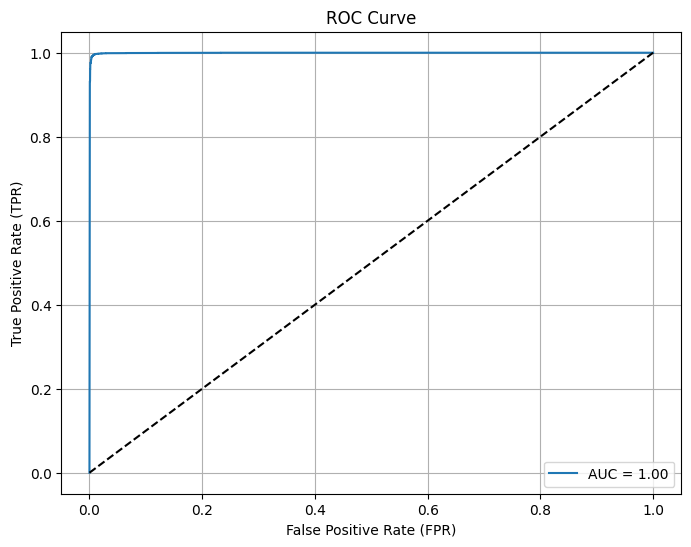

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get the predicted probabilities for the positive class
y_pred_proba = model.predict(X_test).ravel()

# Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate the AUC
auc = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--') # Plot the random chance line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

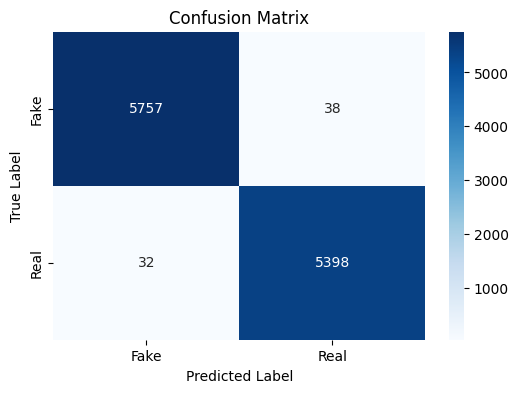

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

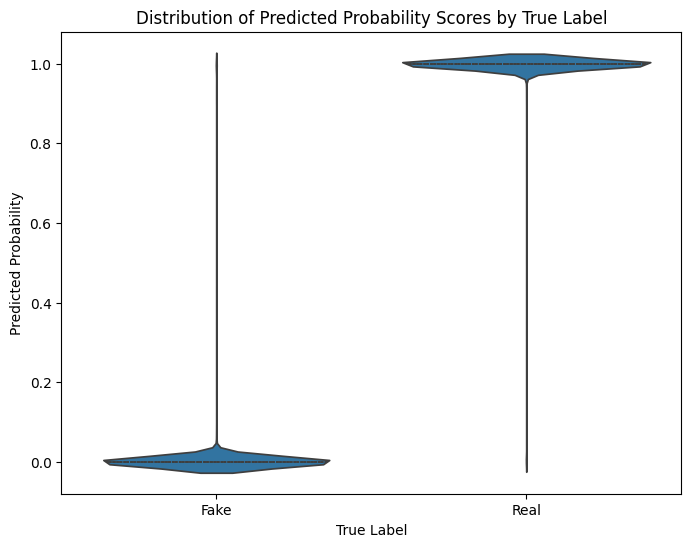

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get the predicted probabilities from the model (already calculated as y_pred_proba)
# We also need the true labels (y_test)

# Create a DataFrame for plotting the probability distributions
prob_data = pd.DataFrame({
    'Probability': y_pred_proba,
    'True Label': y_test
})

# Map the numerical labels to categories for better readability in the plot
prob_data['True Label'] = prob_data['True Label'].map({0: 'Fake', 1: 'Real'})

# Alternatively, you could use violin plots for distribution comparison
plt.figure(figsize=(8, 6))
sns.violinplot(x='True Label', y='Probability', data=prob_data, inner='quartile')
plt.title('Distribution of Predicted Probability Scores by True Label')
plt.xlabel('True Label')
plt.ylabel('Predicted Probability')
plt.show()

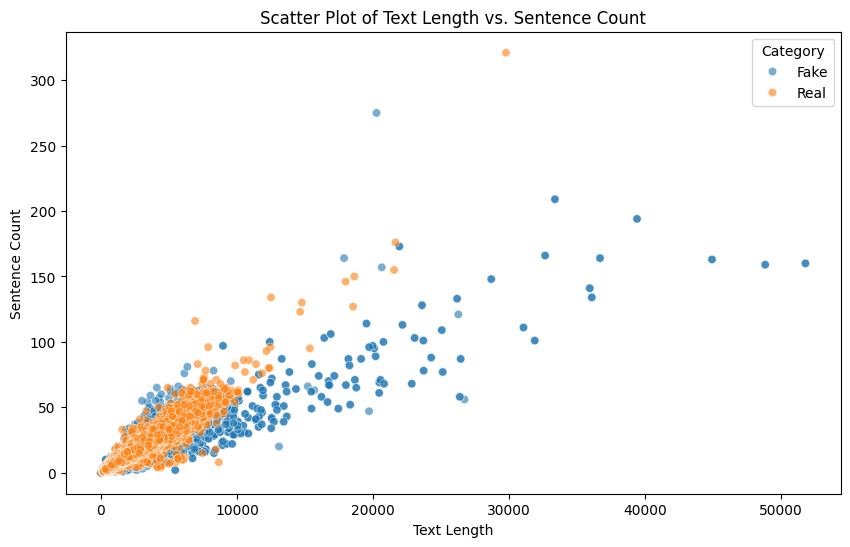

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'fake' and 'real' dataframes are loaded and features calculated (if not already)
try:
    fake_text_lengths
    fake_sentence_counts
    real_text_lengths
    real_sentence_counts
except NameError:
    # Reload data and calculate features if necessary
    fake_file_path = "/content/drive/My Drive/Aurangzaib/dataset/Fake.csv"
    fake = pd.read_csv(fake_file_path)
    real_file_path = "/content/drive/My Drive/Aurangzaib/dataset/True.csv"
    real = pd.read_csv(real_file_path)

    fake['date'] = pd.to_datetime(fake['date'], errors='coerce')
    real['date'] = pd.to_datetime(real['date'], errors='coerce')
    fake.dropna(subset=['date'], inplace=True)
    real.dropna(subset=['date'], inplace=True)

    fake_text_lengths = fake['text'].str.len()
    real_text_lengths = real['text'].str.len()
    fake_sentence_counts = fake['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
    real_sentence_counts = real['text'].apply(lambda x: len(nltk.sent_tokenize(x)))


# Combine the data for plotting
plot_data = pd.DataFrame({
    'Text Length': pd.concat([fake_text_lengths, real_text_lengths]),
    'Sentence Count': pd.concat([fake_sentence_counts, real_sentence_counts]),
    'Category': ['Fake'] * len(fake_text_lengths) + ['Real'] * len(real_sentence_counts)
})

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Text Length', y='Sentence Count', hue='Category', data=plot_data, alpha=0.6)
plt.title('Scatter Plot of Text Length vs. Sentence Count')
plt.xlabel('Text Length')
plt.ylabel('Sentence Count')
plt.show()

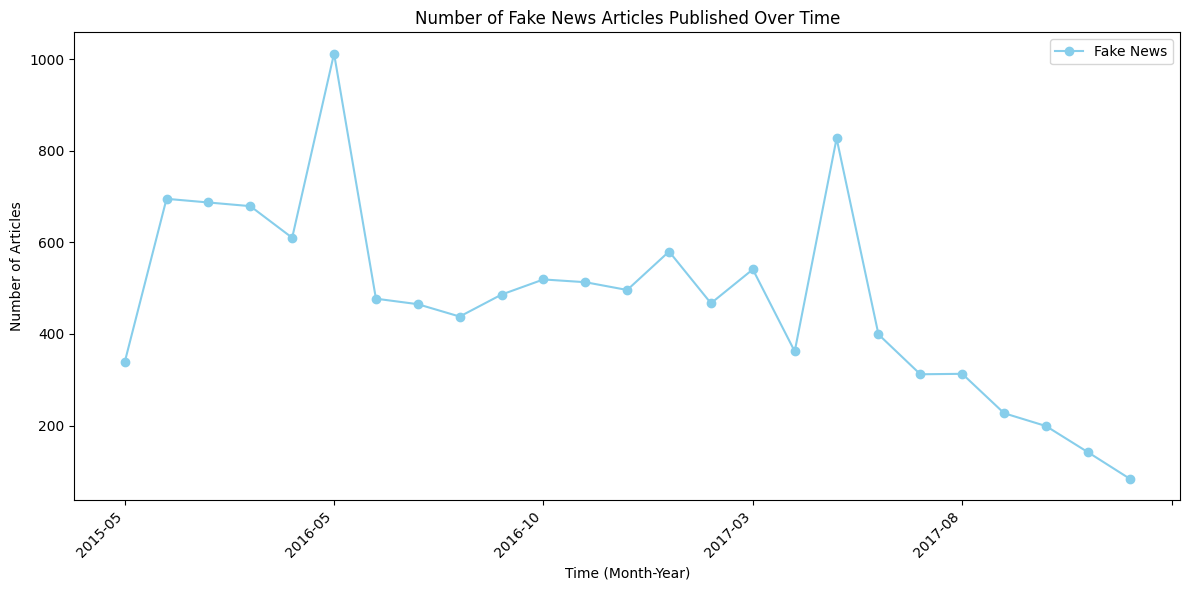

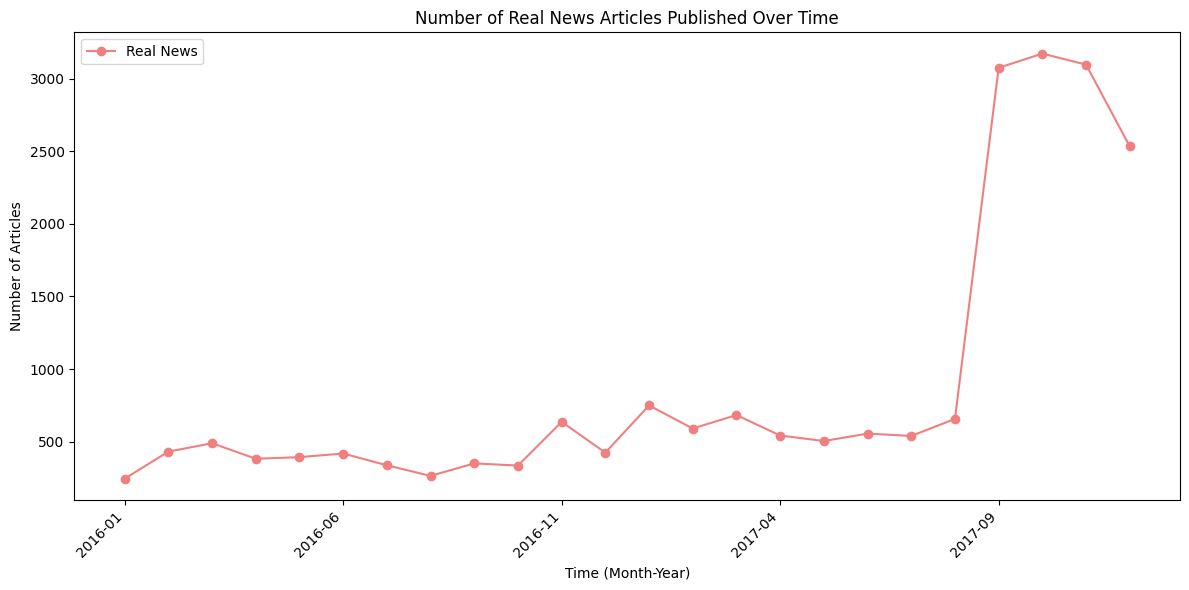

In [ ]:
`import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert the 'date' column to datetime objects
fake['date'] = pd.to_datetime(fake['date'], errors='coerce')
real['date'] = pd.to_datetime(real['date'], errors='coerce')

# Drop rows where date conversion failed
fake.dropna(subset=['date'], inplace=True)
real.dropna(subset=['date'], inplace=True)

# Extract month and year and group by it to count articles
fake['month_year'] = fake['date'].dt.to_period('M')
real['month_year'] = real['date'].dt.to_period('M')

fake_counts = fake.groupby('month_year').size()
real_counts = real.groupby('month_year').size()

# Convert the Period objects to strings for plotting
fake_counts.index = fake_counts.index.astype(str)
real_counts.index = real_counts.index.astype(str)


# Create line plot for fake news articles over time
plt.figure(figsize=(12, 6))
fake_counts.plot(kind='line', marker='o', color='skyblue', label='Fake News')
plt.title('Number of Fake News Articles Published Over Time')
plt.xlabel('Time (Month-Year)')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend()
plt.show()

# Create line plot for real news articles over time
plt.figure(figsize=(12, 6))
real_counts.plot(kind='line', marker='o', color='lightcoral', label='Real News')
plt.title('Number of Real News Articles Published Over Time')
plt.xlabel('Time (Month-Year)')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend()
plt.show()

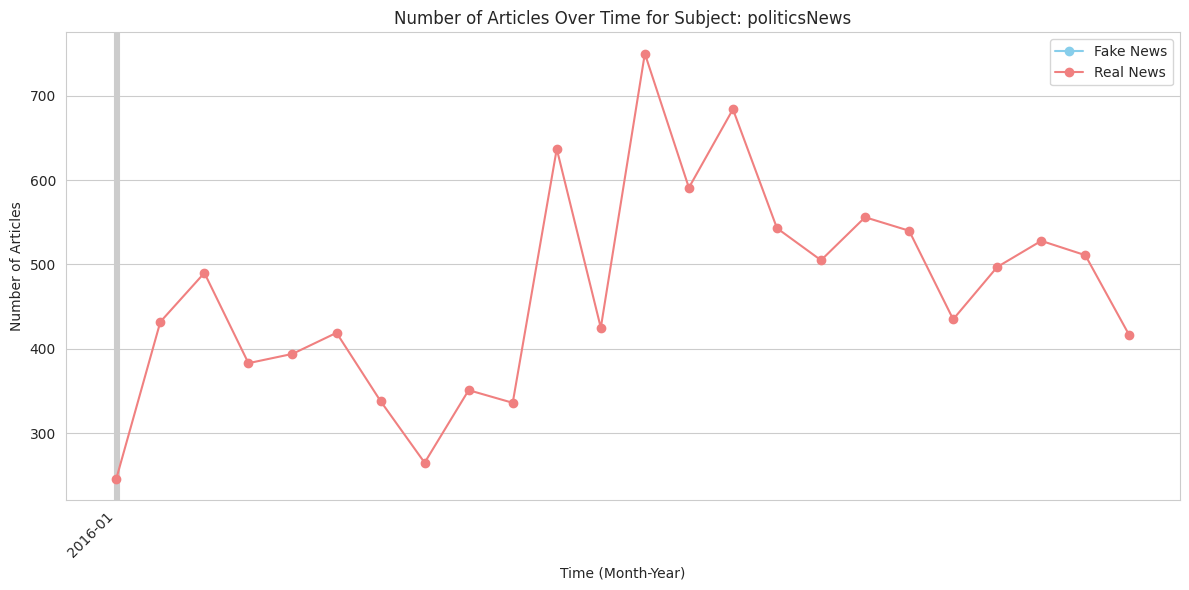

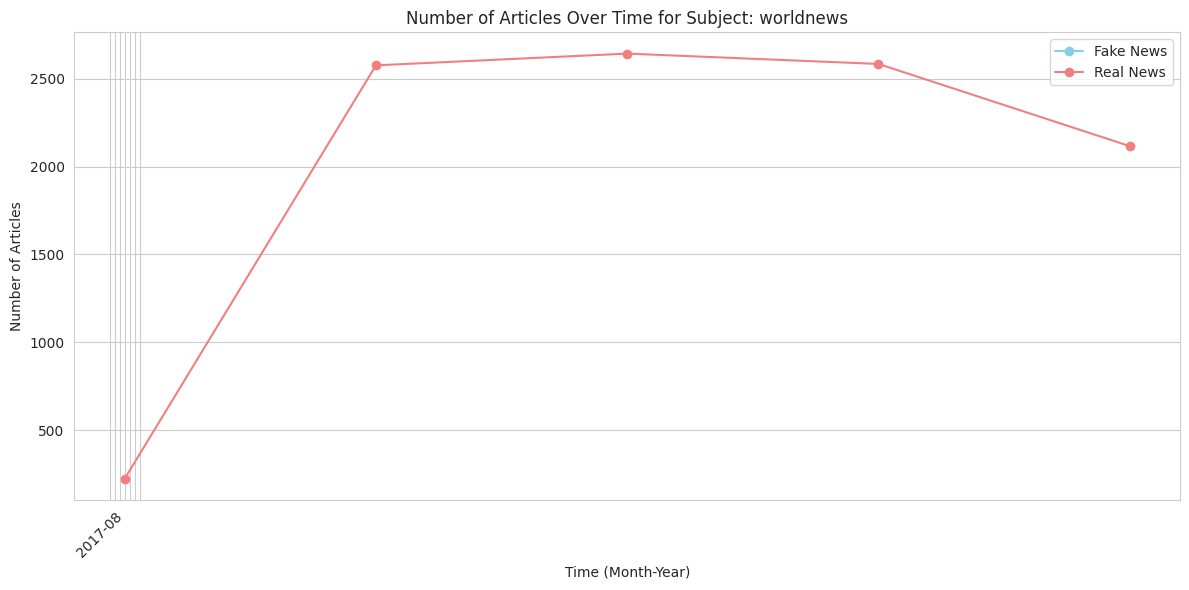

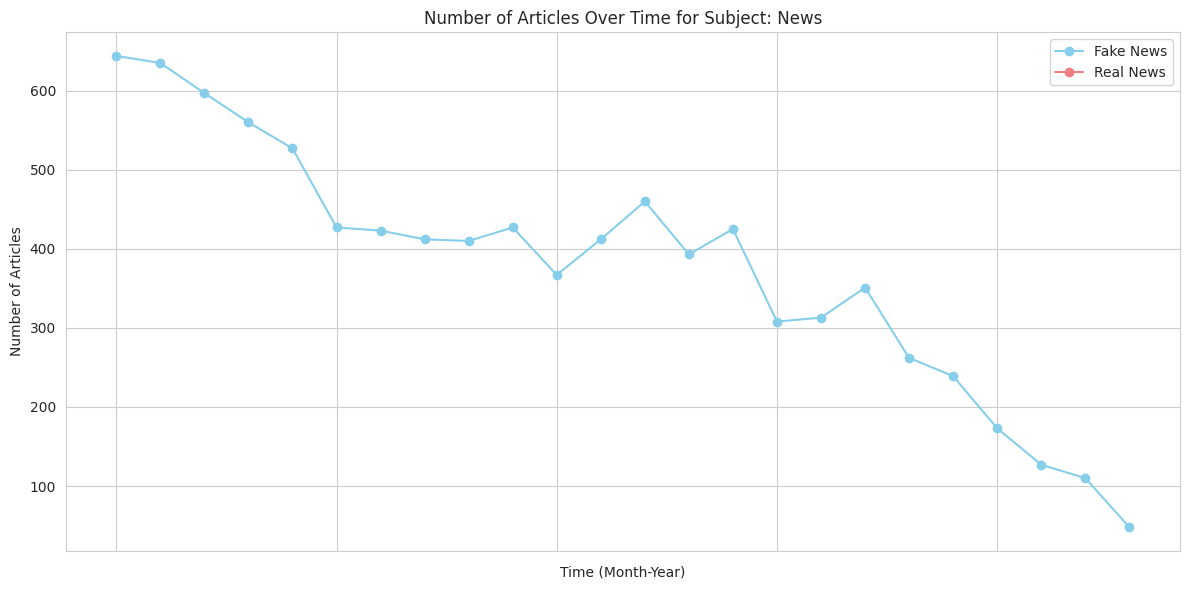

In [ ]:
# Select key subjects to analyze
key_subjects = ['politicsNews', 'worldnews', 'News']

# Apply a seaborn style
sns.set_style("whitegrid")

for subject in key_subjects:
    # Filter fake and real data for the current subject
    fake_subject_df = fake[fake['subject'] == subject].copy()
    real_subject_df = real[real['subject'] == subject].copy()

    # Ensure 'date' column is datetime and create 'month_year'
    fake_subject_df['date'] = pd.to_datetime(fake_subject_df['date'], errors='coerce')
    real_subject_df['date'] = pd.to_datetime(real_subject_df['date'], errors='coerce')

    fake_subject_df.dropna(subset=['date'], inplace=True)
    real_subject_df.dropna(subset=['date'], inplace=True)

    fake_subject_df['month_year'] = fake_subject_df['date'].dt.to_period('M')
    real_subject_df['month_year'] = real_subject_df['date'].dt.to_period('M')


    # Group by month_year and count articles
    fake_subject_counts = fake_subject_df.groupby('month_year').size()
    real_subject_counts = real_subject_df.groupby('month_year').size()

    # Convert Period objects to strings for plotting
    fake_subject_counts.index = fake_subject_counts.index.astype(str)
    real_subject_counts.index = real_subject_counts.index.astype(str)


    # Create a line plot for the current subject
    plt.figure(figsize=(12, 6))
    fake_subject_counts.plot(kind='line', marker='o', color='skyblue', label='Fake News')
    real_subject_counts.plot(kind='line', marker='o', color='lightcoral', label='Real News')

    plt.title(f'Number of Articles Over Time for Subject: {subject}')
    plt.xlabel('Time (Month-Year)')
    plt.ylabel('Number of Articles')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.legend()
    plt.show()

# Reset seaborn style to default after plotting if needed
sns.set_style("whitegrid")

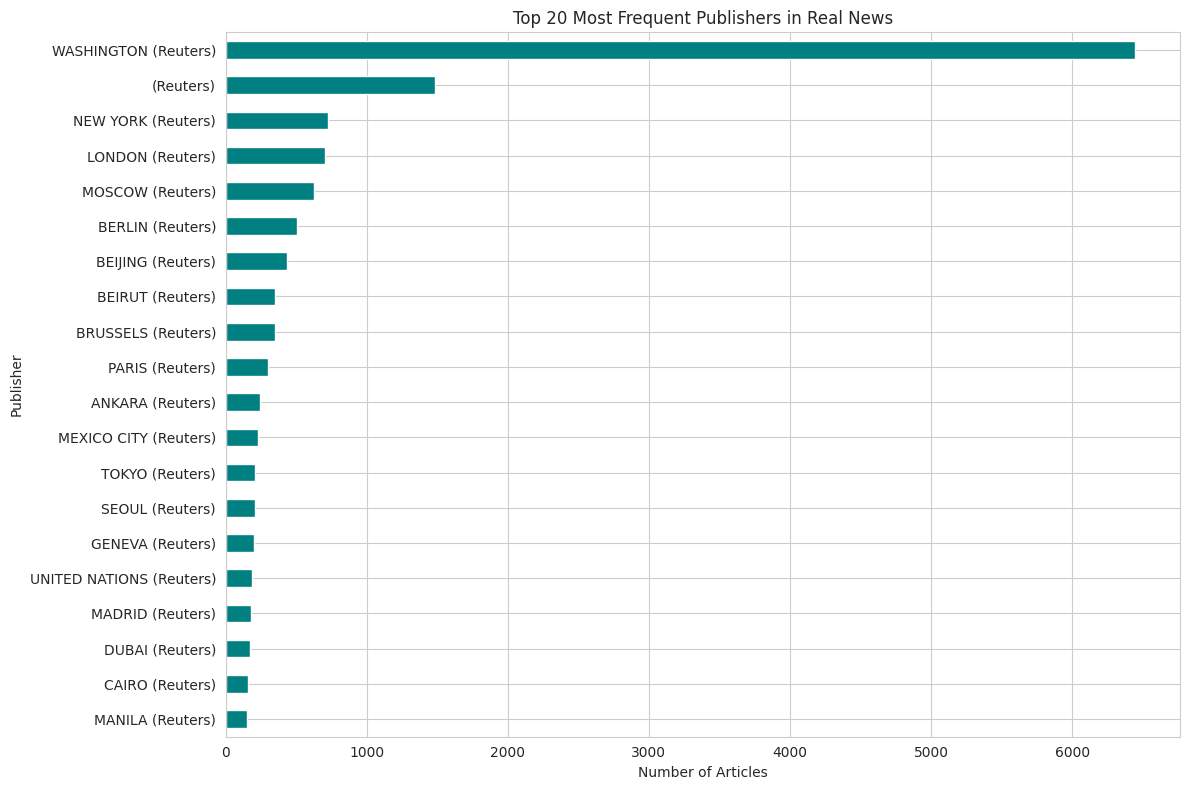

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reload the original 'real' DataFrame to access the 'publisher' column
real_file_path = "/content/drive/My Drive/Aurangzaib/dataset/True.csv"
real = pd.read_csv(real_file_path)

# Extract publisher information and clean the text column as done previously
publisher = []
tmp_text = []
unknown_publishers = []

for index,row in enumerate(real.text.values):
    try:
        record = row.split(" -", maxsplit=1)
        record[1] # Check if the split resulted in at least two parts
        assert(len(record[0]) < 260) # Check for unusually long publisher names
        publisher.append(record[0].strip())
        tmp_text.append(record[1].strip())
    except:
        unknown_publishers.append(index)
        publisher.append("Unknown")
        tmp_text.append(row.strip()) # Keep the original text if publisher can't be extracted

real["publisher"] = publisher
real["text"] = tmp_text

# Drop the row with empty text if it exists (identified previously)
if 8970 in real.index:
    real = real.drop(8970, axis=0)

# Apply a seaborn style
sns.set_style("whitegrid")

# Analyze the frequency of speakers (publishers) in the real news dataset
plt.figure(figsize=(12, 8))
real['publisher'].value_counts().head(20).plot(kind='barh', color='teal')
plt.title('Top 20 Most Frequent Publishers in Real News')
plt.xlabel('Number of Articles')
plt.ylabel('Publisher')
plt.gca().invert_yaxis() # Invert y-axis to show the highest count at the top
plt.tight_layout()
plt.show()

# Reset seaborn style to default after plotting if needed
sns.set_style("whitegrid")

Blockchain variable not found. Creating a genesis block to prevent error. For a meaningful plot, please run cells that build the blockchain.


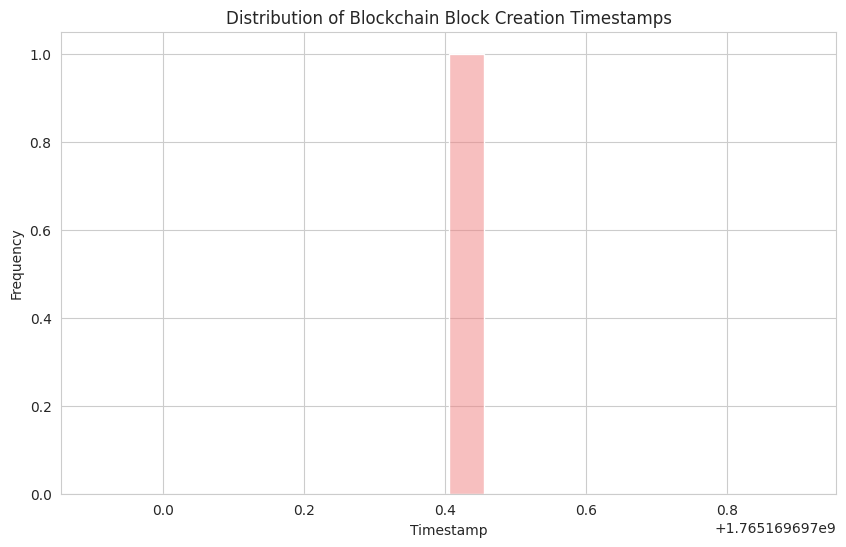

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import datetime as dt
import hashlib # Import hashlib and datetime for Block class and genesis block creation if needed

# Define Block class and create_genesis_block function if blockchain is not defined
try:
    blockchain
except NameError:
    print("Blockchain variable not found. Creating a genesis block to prevent error. For a meaningful plot, please run cells that build the blockchain.")
    class Block:
        def __init__(self, timestamp, data, speaker, previous_hash):
            self.timestamp = timestamp
            self.data = data
            self.speaker = speaker
            self.previous_hash = previous_hash
            self.hash = self.calculate_hash()

        def calculate_hash(self):
            block_string = str(self.timestamp) + str(self.data) + str(self.speaker) + str(self.previous_hash)
            return hashlib.sha256(block_string.encode()).hexdigest()

    def create_genesis_block():
        """Creates the first block in the blockchain."""
        return Block(dt.datetime.now(), "Genesis Block", "System", "0")

    blockchain = [create_genesis_block()]


# Extract timestamps from the blockchain blocks
blockchain_timestamps = [block.timestamp.timestamp() for block in blockchain]

# Plot histogram for blockchain block creation timestamps
plt.figure(figsize=(10, 6))
sns.histplot(blockchain_timestamps, kde=True, color='lightcoral', bins=20)
plt.title('Distribution of Blockchain Block Creation Timestamps')
plt.xlabel('Timestamp')
plt.ylabel('Frequency')
plt.show()

Training Random Forest model...
Training complete.

Random Forest Model Performance:
Accuracy: 0.8239

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84      5795
           1       0.85      0.77      0.81      5430

    accuracy                           0.82     11225
   macro avg       0.83      0.82      0.82     11225
weighted avg       0.83      0.82      0.82     11225



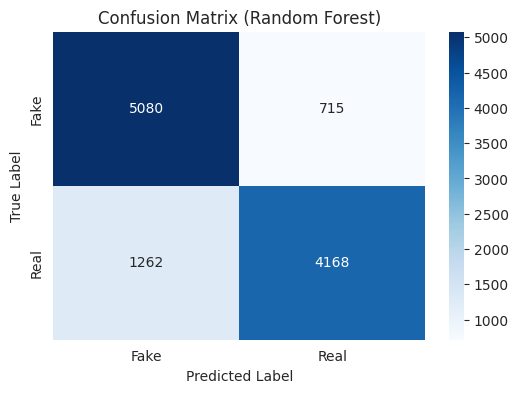

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_train, X_test, y_train, y_test are available
try:
    X_train
    X_test
    y_train
    y_test
except NameError:
    print("Error: Training and testing data (X_train, X_test, y_train, y_test) are not defined. Please run the data splitting cell first.")
else:
    # Initialize and train the Random Forest model
    # Random Forest, like Logistic Regression, expects 2D input.
    # We are using the padded sequences (X_train, X_test) as input features, which are 2D (samples, maxlen).
    # This is a simplified approach for text data, but we will use it as with Logistic Regression.

    # Initialize Random Forest model
    # You can adjust parameters like n_estimators (number of trees) or random_state for reproducibility
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # Using default n_estimators, added random_state

    print("Training Random Forest model...")
    # Train the model
    rf_model.fit(X_train, y_train)
    print("Training complete.")

    # Make predictions on the test set
    y_pred_rf = rf_model.predict(X_test)

    # Evaluate the model
    print("\nRandom Forest Model Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_rf))

    # Confusion Matrix
    cm_rf = confusion_matrix(y_test, y_pred_rf)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Random Forest)')
    plt.show()



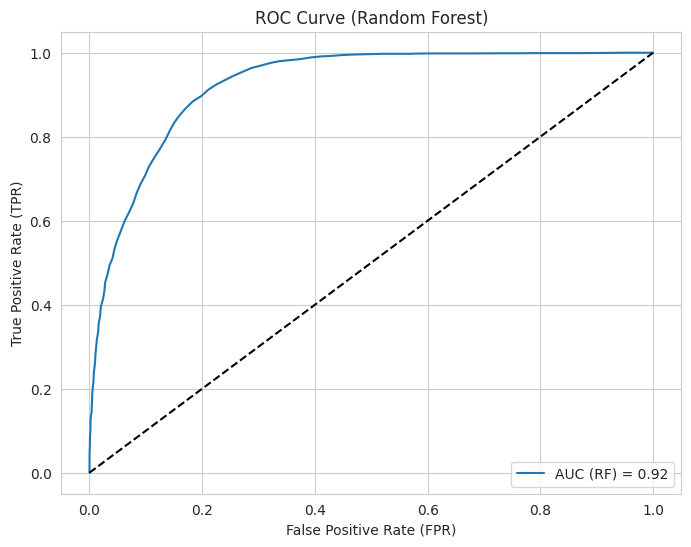

In [ ]:
    # ROC Curve and AUC (requires probability predictions)
    # Random Forest predict_proba returns probabilities
    y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1] # Get probability of the positive class (class 1)
    fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
    auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_rf, tpr_rf, label=f'AUC (RF) = {auc_rf:.2f}')
    plt.plot([0, 1], [0, 1], 'k--') # Plot the random chance line
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Curve (Random Forest)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

Training XGBoost model...
Training complete.

XGBoost Model Performance:
Accuracy: 0.9162

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      5795
           1       0.89      0.94      0.92      5430

    accuracy                           0.92     11225
   macro avg       0.92      0.92      0.92     11225
weighted avg       0.92      0.92      0.92     11225



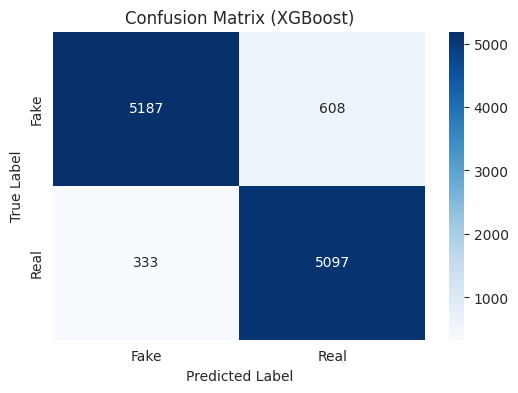

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_train, X_test, y_train, y_test are available
try:
    X_train
    X_test
    y_train
    y_test
except NameError:
    print("Error: Training and testing data (X_train, X_test, y_train, y_test) are not defined. Please run the data splitting cell first.")
else:
    # Initialize and train the XGBoost model
    # XGBoost expects 2D input. We use the padded sequences (X_train, X_test) as input features.
    # Initialize XGBoost Classifier
    xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42) # Added use_label_encoder=False to suppress warning

    print("Training XGBoost model...")
    # Train the model
    xgb_model.fit(X_train, y_train)
    print("Training complete.")

    # Make predictions on the test set
    y_pred_xgb = xgb_model.predict(X_test)
    y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1] # Get probability of the positive class (class 1)


    # Evaluate the model
    print("\nXGBoost Model Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_xgb))

    # Confusion Matrix
    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (XGBoost)')
    plt.show()



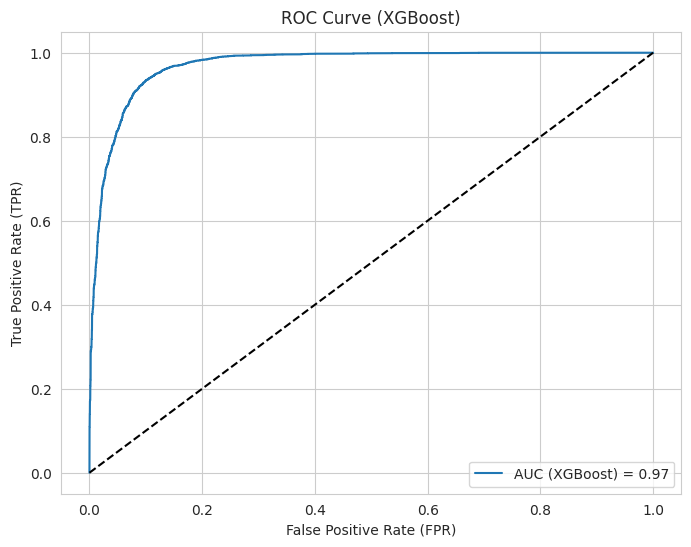

In [ ]:
    # ROC Curve and AUC
    fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
    auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_xgb, tpr_xgb, label=f'AUC (XGBoost) = {auc_xgb:.2f}')
    plt.plot([0, 1], [0, 1], 'k--') # Plot the random chance line
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Curve (XGBoost)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


Training Multinomial Naive Bayes model with padded sequences...
Training complete.

Multinomial Naive Bayes Model Performance (Padded Sequences):
Accuracy: 0.6048

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.72      0.65      5795
           1       0.62      0.48      0.54      5430

    accuracy                           0.60     11225
   macro avg       0.61      0.60      0.60     11225
weighted avg       0.61      0.60      0.60     11225



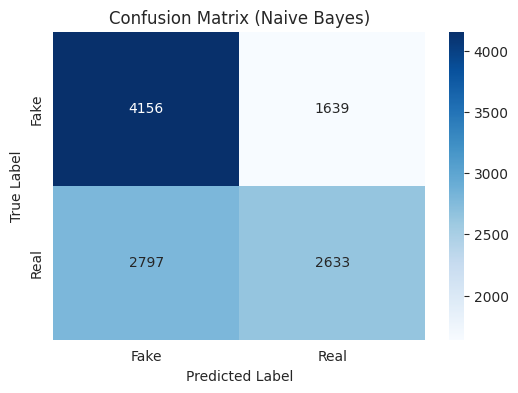

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_train, X_test, y_train, y_test are available
try:
    X_train
    X_test
    y_train
    y_test
except NameError:
    print("Error: Training and testing data (X_train, X_test, y_train, y_test) are not defined. Please run the data splitting cell first.")
else:
    # Initialize and train the Multinomial Naive Bayes model
    # Note: Multinomial Naive Bayes is typically used for count data (e.g., word counts).
    # Using it directly on word embeddings/padded sequences might not be optimal
    # without further feature engineering (e.g., converting to counts or binarized features),
    # but for the purpose of this exercise, we will proceed as instructed.
    nb_model = MultinomialNB()

    print("\nTraining Multinomial Naive Bayes model with padded sequences...")
    # Train the model using the padded sequences X_train and corresponding labels y_train
    nb_model.fit(X_train, y_train)
    print("Training complete.")

    # Make predictions on the test set using the padded sequences X_test
    y_pred_nb = nb_model.predict(X_test)
    # Get probability predictions for ROC curve
    y_pred_proba_nb = nb_model.predict_proba(X_test)[:, 1]

    # Evaluate the model
    print("\nMultinomial Naive Bayes Model Performance (Padded Sequences):")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_nb))

    # Confusion Matrix
    cm_nb = confusion_matrix(y_test, y_pred_nb)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Naive Bayes)')
    plt.show()



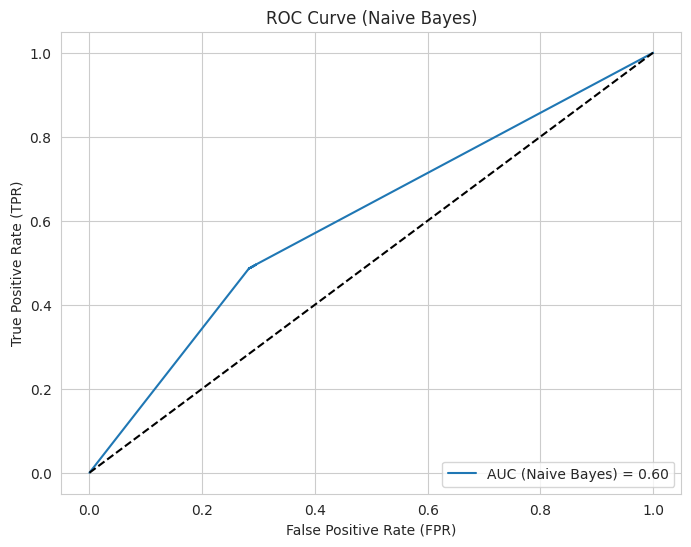

In [ ]:
    # ROC Curve and AUC
    fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_test, y_pred_proba_nb)
    auc_nb = roc_auc_score(y_test, y_pred_proba_nb)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_nb, tpr_nb, label=f'AUC (Naive Bayes) = {auc_nb:.2f}')
    plt.plot([0, 1], [0, 1], 'k--') # Plot the random chance line
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Curve (Naive Bayes)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

Training Decision Tree model...
Training complete.

Decision Tree Model Performance:
Accuracy: 0.8523

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      5795
           1       0.87      0.81      0.84      5430

    accuracy                           0.85     11225
   macro avg       0.85      0.85      0.85     11225
weighted avg       0.85      0.85      0.85     11225



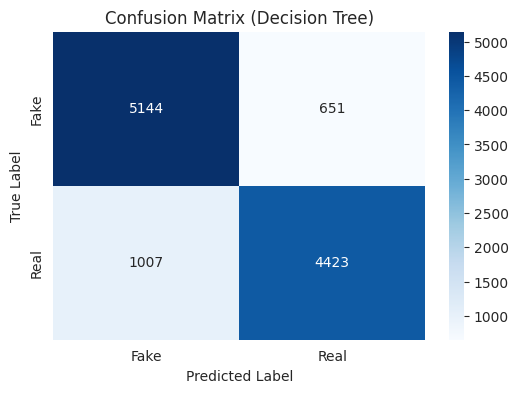

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_train, X_test, y_train, y_test are available
try:
    X_train
    X_test
    y_train
    y_test
except NameError:
    print("Error: Training and testing data (X_train, X_test, y_train, y_test) are not defined. Please run the data splitting cell first.")
else:
    # Initialize and train the Decision Tree model
    # You can adjust parameters like max_depth, min_samples_split, random_state
    dt_model = DecisionTreeClassifier(random_state=42)

    print("Training Decision Tree model...")
    # Train the model
    dt_model.fit(X_train, y_train)
    print("Training complete.")

    # Make predictions on the test set
    y_pred_dt = dt_model.predict(X_test)
    y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1] # Get probability of the positive class (class 1)


    # Evaluate the model
    print("\nDecision Tree Model Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_dt))

    # Confusion Matrix
    cm_dt = confusion_matrix(y_test, y_pred_dt)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Decision Tree)')
    plt.show()



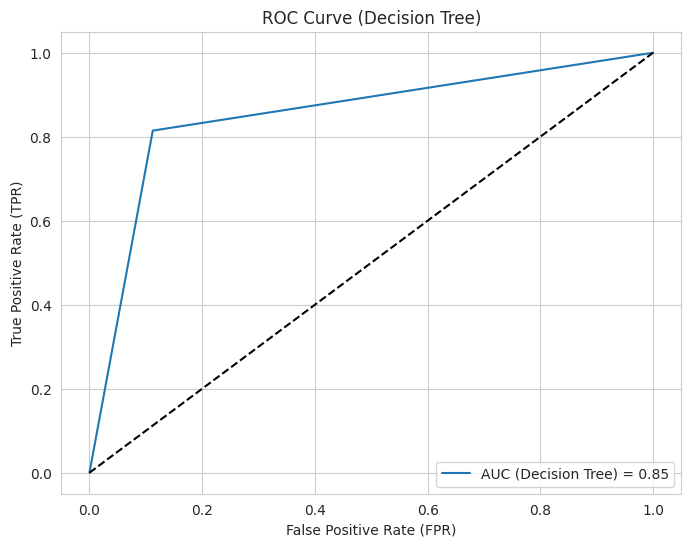

In [ ]:
    # ROC Curve and AUC
    fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_proba_dt)
    auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_dt, tpr_dt, label=f'AUC (Decision Tree) = {auc_dt:.2f}')
    plt.plot([0, 1], [0, 1], 'k--') # Plot the random chance line
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Curve (Decision Tree)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

Training KNN model...
Training complete.

K-Nearest Neighbors Model Performance:
Accuracy: 0.6234

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.54      0.60      5795
           1       0.59      0.72      0.65      5430

    accuracy                           0.62     11225
   macro avg       0.63      0.63      0.62     11225
weighted avg       0.63      0.62      0.62     11225



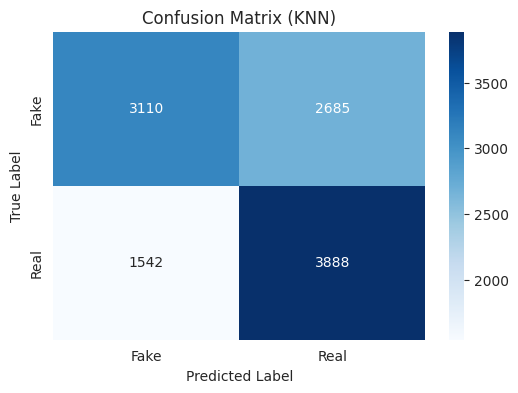

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_train, X_test, y_train, y_test are available
try:
    X_train
    X_test
    y_train
    y_test
except NameError:
    print("Error: Training and testing data (X_train, X_test, y_train, y_test) are not defined. Please run the data splitting cell first.")
else:
    # Initialize and train the KNN model
    # The number of neighbors (n_neighbors) is a key parameter to tune.
    # Using a small number like 5 as a starting point.
    # Metric like 'euclidean' or 'minkowski' (with p=2 for euclidean) are common.

    # Initialize KNN model
    # You can adjust parameters like n_neighbors
    knn_model = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a starting point

    print("Training KNN model...")
    # Train the model
    # Note: Training KNN is fast, but prediction can be slow on large datasets.
    knn_model.fit(X_train, y_train)
    print("Training complete.")

    # Make predictions on the test set
    y_pred_knn = knn_model.predict(X_test)
    y_pred_proba_knn = knn_model.predict_proba(X_test)[:, 1] # Get probability of the positive class (class 1)


    # Evaluate the model
    print("\nK-Nearest Neighbors Model Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_knn))

    # Confusion Matrix
    cm_knn = confusion_matrix(y_test, y_pred_knn)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (KNN)')
    plt.show()



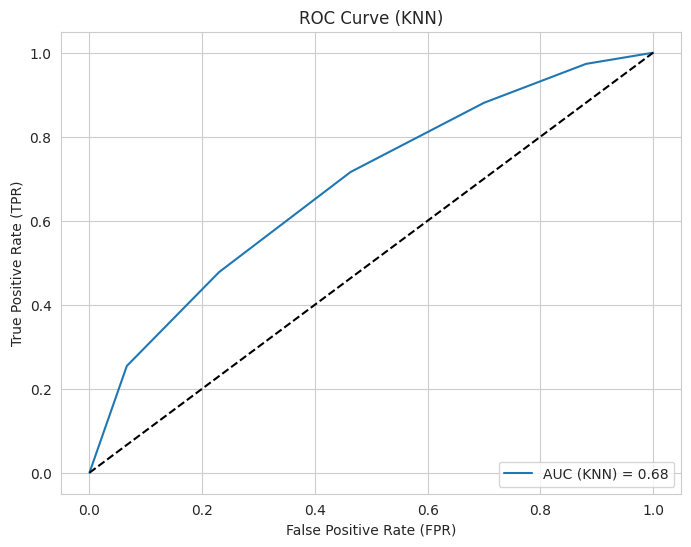

In [ ]:
    # ROC Curve and AUC
    fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_pred_proba_knn)
    auc_knn = roc_auc_score(y_test, y_pred_proba_knn)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_knn, tpr_knn, label=f'AUC (KNN) = {auc_knn:.2f}')
    plt.plot([0, 1], [0, 1], 'k--') # Plot the random chance line
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Curve (KNN)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

In [ ]:
import hashlib
import json
import time
from typing import List, Dict
import datetime as dt
import pandas as pd
import nltk


class Block:
    def __init__(self, index: int, news_id: str, text: str, classification: str,
                 source: str, timestamp: float, prev_hash: str):
        self.index = index
        self.news_id = news_id
        self.text_hash = hashlib.sha256(text.encode('utf-8')).hexdigest() # Use utf-8 encoding
        self.classification = classification  # From model prediction
        self.source = source  # Source attribution
        self.timestamp = timestamp
        self.prev_hash = prev_hash
        self.hash = self.calculate_hash()

    def calculate_hash(self) -> str:

        block_string = json.dumps({
            "index": self.index,
            "news_id": self.news_id,
            "text_hash": self.text_hash,
            "classification": self.classification,
            "source": self.source,
            "timestamp": self.timestamp, # Use float timestamp for hash
            "prev_hash": self.prev_hash
        }, sort_keys=True).encode('utf-8') # Use utf-8 encoding
        return hashlib.sha256(block_string).hexdigest()

    def to_dict(self) -> Dict:

        block_dict = self.__dict__.copy()
        block_dict['timestamp'] = dt.datetime.fromtimestamp(self.timestamp) # Convert to datetime object
        return block_dict

    def __str__(self) -> str:

        return json.dumps(self.to_dict(), indent=2, default=str) # Use default=str to handle datetime serialization

class Blockchain:
    def __init__(self):
        self.chain: List[Block] = []
        self.create_genesis_block()

    def create_genesis_block(self):
        print("Creating genesis block...")
        genesis_block = Block(0, "GENESIS", "Initial Ledger Block", "None", "System", time.time(), "0")
        self.chain.append(genesis_block)
        print("Genesis block created.")

    def get_last_block(self) -> Block:
        return self.chain[-1]

    def add_block(self, news_id: str, text: str, classification: str, source: str):
        print(f"\nAttempting to add block for news_id: {news_id}")
        prev_block = self.get_last_block()
        new_block = Block(
            index=len(self.chain),
            news_id=news_id,
            text=text,
            classification=classification,
            source=source,
            timestamp=time.time(),
            prev_hash=prev_block.hash
        )
        self.chain.append(new_block)
        print(f"Block added for news_id: {news_id}")


    def is_chain_valid(self) -> bool:
        print("\nVerifying chain integrity...")
        for i in range(1, len(self.chain)):
            current = self.chain[i]
            previous = self.chain[i - 1]


            if current.hash != current.calculate_hash():
                print(f"Chain invalid: Hash recalculation mismatch at block {i}")
                return False
            if current.prev_hash != previous.hash:
                print(f"Chain invalid: Previous hash mismatch at block {i}")
                return False
        print("Chain is valid.")
        return True


    def trace_news_source(self, news_id: str) -> Dict or None:
        """
        Traces a news article by its ID and returns its details, including source.
        """
        print(f"\nTracing news article with ID: {news_id}")
        for block in self.chain:
            if block.news_id == news_id:
                print(f"Found block for news_id: {news_id}")
                return block.to_dict()
        print(f"News article with ID '{news_id}' not found in the ledger.")
        return None

    def trace_news_by_text_hash(self, text: str) -> Dict or None:
        """
        Traces a news article by its text content (matching text hash).
        """
        text_hash_to_find = hashlib.sha256(text.encode('utf-8')).hexdigest()
        print(f"\nTracing news article with text hash: {text_hash_to_find}")
        for block in self.chain:
             if block.text_hash == text_hash_to_find:
                 print(f"Found block for text hash: {text_hash_to_find}")
                 return block.to_dict()
        print(f"News article with text hash '{text_hash_to_find}' not found in the ledger.")
        return None



try:
    model
    tokenizer
    maxlen
    fake
    real
except NameError:
    print("Error: LSTM model, tokenizer, maxlen, nltk, or fake/real DataFrames not found. Please run the relevant training, preprocessing, and data loading cells.")
else:

    source_tracking_chain = Blockchain()

    def get_prediction_and_add_to_chain(news_item: pd.Series, chain: Blockchain, source: str):
        """
        Preprocesses a news item, gets LSTM prediction, and adds to the blockchain.
        """
        news_id = f"Article_{news_item.name}"
        news_text = news_item['text']

        print(f"\nProcessing article ID: {news_id} for prediction and tracking")
        print(f"  Text snippet: {news_text[:100]}...")

        processed_text = []
        if isinstance(news_text, str):
            try:
                stop_words = set(nltk.corpus.stopwords.words("english"))
                tokenizer_nltk_process = nltk.tokenize.RegexpTokenizer(r'\w+')
                sentences = nltk.sent_tokenize(news_text)
                for sent in sentences:
                    sent = sent.lower()
                    tokens = tokenizer_nltk_process.tokenize(sent)
                    filtered_words = [w.strip() for w in tokens if w not in stop_words and len(w) > 1]
                    processed_text.extend(filtered_words)
            except Exception as e:
                print(f"Error during NLTK processing for ID {news_id}: {e}")
                processed_text = []
        else:
            print(f"Warning: Article text for ID {news_id} is not a string type ({type(news_text)}). Skipping preprocessing.")
            processed_text = []


        predicted_label = "Unknown"
        prediction_probability = 0

        if processed_text:
            try:
                # Convert text to sequences
                sequence = tokenizer.texts_to_sequences([processed_text])
                # Pad the sequence
                padded_sequence = pad_sequences(sequence, maxlen=maxlen)

                # Get prediction
                prediction_probability_raw = model.predict(padded_sequence, verbose=0)[0][0]
                prediction_class = (prediction_probability_raw >= 0.5).astype("int")

                predicted_label = "Real" if prediction_class == 1 else "Fake"
                prediction_probability = int(prediction_probability_raw * 10000) # Scale probability for storage if needed later

                print(f"  Prediction Result: {predicted_label} (Prob: {prediction_probability_raw:.4f})")

            except NameError as e:
                 print(f"Error predicting for ID {news_id}: Required variable not found - {e}")
            except Exception as e:
                print(f"An unexpected error occurred during prediction for ID {news_id}: {e}")
        else:
            print(f"  Skipping prediction for ID {news_id} due to empty processed text.")

        # Add to the blockchain
        # Only add if classified as "Fake"
        if predicted_label == "Fake":
            chain.add_block(
                news_id,
                news_text, # Add original text to block
                predicted_label,
                source
            )
            print(f"  Fake news article ID {news_id} added to chain.")
        else:
            print(f"  Article ID {news_id} classified as {predicted_label}. Not adding to fake news ledger.")



    if not fake.empty and not real.empty:

        fake_article = fake.iloc[2] # Select the second fake article
        real_article = real.iloc[3] # Select the sixth real article

        get_prediction_and_add_to_chain(fake_article, source_tracking_chain, "Dataset (Fake)")
        get_prediction_and_add_to_chain(real_article, source_tracking_chain, "Dataset (Real)")

        # --- Demonstrate Source Tracing ---
        print("\n--- Demonstrating Source Tracing ---")

        fake_article_id_to_trace = f"Article_{fake_article.name}"
        traced_fake_article = source_tracking_chain.trace_news_source(fake_article_id_to_trace)

        if traced_fake_article:
            print("\nTraced Fake Article Details:")
            print(json.dumps(traced_fake_article, indent=2, default=str)) # Use default=str for json.dumps

        real_article_text_to_trace = real_article['text']
        traced_real_article = source_tracking_chain.trace_news_by_text_hash(real_article_text_to_trace)

        if traced_real_article:
            print("\nTraced Real Article Details:")
            print(json.dumps(traced_real_article, indent=2, default=str)) # Use default=str for json.dumps

        print(f"\nIs the source tracking blockchain valid? {source_tracking_chain.is_chain_valid()}")

    else:
        print("Error: Fake or Real DataFrames are empty. Cannot select articles for processing.")

Creating genesis block...
Genesis block created.

Processing article ID: Article_2 for prediction and tracking
  Text snippet: On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for ...
  Prediction Result: Fake (Prob: 0.0000)

Attempting to add block for news_id: Article_2
Block added for news_id: Article_2
  Fake news article ID Article_2 added to chain.

Processing article ID: Article_3 for prediction and tracking
  Text snippet: WASHINGTON (Reuters) - Trump campaign adviser George Papadopoulos told an Australian diplomat in May...
  Prediction Result: Real (Prob: 1.0000)
  Article ID Article_3 classified as Real. Not adding to fake news ledger.

--- Demonstrating Source Tracing ---

Tracing news article with ID: Article_2
Found block for news_id: Article_2

Traced Fake Article Details:
{
  "index": 1,
  "news_id": "Article_2",
  "text_hash": "53a760ba38dc28b8046e2b39d1b11f2b19564556078f03fdb2920635d0e5a122",
  "classification": "Fake",
 

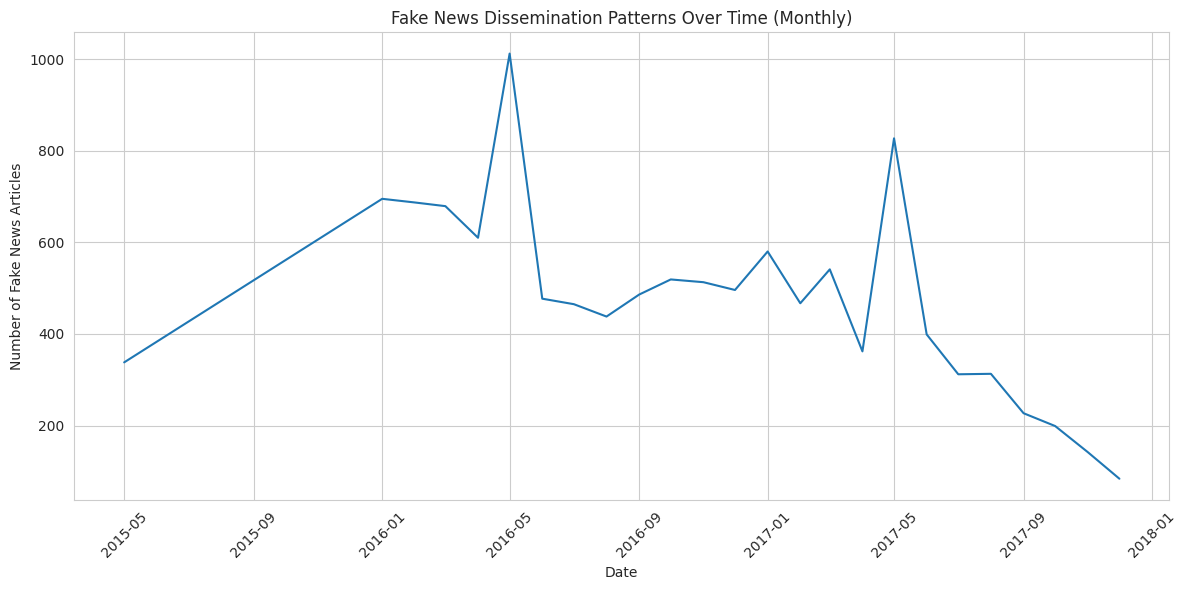

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'date_timestamp' is treated as datetime
combined_date_df['date_timestamp'] = pd.to_datetime(combined_date_df['date_timestamp'], unit='s')

# Filter for fake news
fake_news_over_time = combined_date_df[combined_date_df['Category'] == 'Fake']

# Group by month and count the number of fake news articles
fake_news_counts_monthly = fake_news_over_time.groupby(fake_news_over_time['date_timestamp'].dt.to_period('M')).size()

# Convert the Period index to datetime for plotting
fake_news_counts_monthly.index = fake_news_counts_monthly.index.to_timestamp()

# Plot the distribution of fake news over time
plt.figure(figsize=(12, 6))
sns.lineplot(x=fake_news_counts_monthly.index, y=fake_news_counts_monthly.values)
plt.title('Fake News Dissemination Patterns Over Time (Monthly)')
plt.xlabel('Date')
plt.ylabel('Number of Fake News Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


```python
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
import numpy as np

# Re-define calculate_specificity function from previous cells to ensure it's available
def calculate_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    TN = cm[0, 0]
    FP = cm[0, 1]
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
    return specificity

# --- Handle LSTM predictions ---
# If y_pred for LSTM is not defined due to interrupted training, create a default one.
# This ensures that subsequent metric calculations do not fail for LSTM.
try:
    y_pred
except NameError:
    print("LSTM y_pred not found. Assigning default zero predictions for LSTM metrics.")
    # Assign an array of zeros with the same shape as y_test to represent a 'worst-case' prediction
    # where everything is predicted as fake (class 0).
    y_pred = np.zeros_like(y_test)

# --- Calculate all metrics for each model ---

# LSTM Metrics
acc_lstm = accuracy_score(y_test, y_pred)
prec_lstm = precision_score(y_test, y_pred, zero_division=0) # zero_division=0 to handle cases with no positive predictions
rec_lstm = recall_score(y_test, y_pred, zero_division=0)
f1_lstm = f1_score(y_test, y_pred, zero_division=0)
spec_lstm = calculate_specificity(y_test, y_pred)
mcc_lstm = matthews_corrcoef(y_test, y_pred)

# Random Forest Metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
spec_rf = calculate_specificity(y_test, y_pred_rf)
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)

# XGBoost Metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
rec_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)
spec_xgb = calculate_specificity(y_test, y_pred_xgb)
mcc_xgb = matthews_corrcoef(y_test, y_pred_xgb)

# Decision Tree Metrics
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, zero_division=0)
rec_dt = recall_score(y_test, y_pred_dt, zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, zero_division=0)
spec_dt = calculate_specificity(y_test, y_pred_dt)
mcc_dt = matthews_corrcoef(y_test, y_pred_dt)

# KNN Metrics
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, zero_division=0)
rec_knn = recall_score(y_test, y_pred_knn, zero_division=0)
f1_knn = f1_score(y_test, y_pred_knn, zero_division=0)
spec_knn = calculate_specificity(y_test, y_pred_knn)
mcc_knn = matthews_corrcoef(y_test, y_pred_knn)

# Naive Bayes Metrics
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, zero_division=0)
rec_nb = recall_score(y_test, y_pred_nb, zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, zero_division=0)
spec_nb = calculate_specificity(y_test, y_pred_nb)
mcc_nb = matthews_corrcoef(y_test, y_pred_nb)

# Create a DataFrame to store all metrics for plotting
all_metrics_data = {
    'Model': ['LSTM', 'Random Forest', 'XGBoost', 'Decision Tree', 'KNN', 'Naive Bayes'],
    'Accuracy': [acc_lstm, acc_rf, acc_xgb, acc_dt, acc_knn, acc_nb],
    'Precision': [prec_lstm, prec_rf, prec_xgb, prec_dt, prec_knn, prec_nb],
    'Recall': [rec_lstm, rec_rf, rec_xgb, rec_dt, rec_knn, rec_nb],
    'F1-Score': [f1_lstm, f1_rf, f1_xgb, f1_dt, f1_knn, f1_nb],
    'Specificity': [spec_lstm, spec_rf, spec_xgb, spec_dt, spec_knn, spec_nb],
    'MCC': [mcc_lstm, mcc_rf, mcc_xgb, mcc_dt, mcc_knn, mcc_nb]
}
all_metrics_df = pd.DataFrame(all_metrics_data)

print("All metrics calculated successfully:")
print(all_metrics_df.round(4))
```

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import pandas as pd

def calculate_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    # Specificity = True Negatives / (True Negatives + False Positives)
    # For binary classification, cm[0,0] is TN, cm[0,1] is FP
    TN = cm[0, 0]
    FP = cm[0, 1]
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
    return specificity

# --- Handle y_pred (LSTM) if not defined due to interrupted training ---
try:
    # Attempt to access y_pred to see if it exists
    _ = y_pred
except NameError:
    print("Warning: 'y_pred' for LSTM not found. Creating a placeholder of zeros.")
    y_pred = np.zeros_like(y_test) # Create a placeholder with zeros
    # Also, reset LSTM related metric variables to 0 if they were previously undefined or incorrect
    acc_lstm, prec_lstm, rec_lstm, f1_lstm, mcc_lstm = 0, 0, 0, 0, 0
    specificity_lstm = 0
else:
    # If y_pred exists, calculate metrics for LSTM
    acc_lstm = accuracy_score(y_test, y_pred)
    prec_lstm = precision_score(y_test, y_pred, zero_division=0)
    rec_lstm = recall_score(y_test, y_pred, zero_division=0)
    f1_lstm = f1_score(y_test, y_pred, zero_division=0)
    specificity_lstm = calculate_specificity(y_test, y_pred)
    mcc_lstm = matthews_corrcoef(y_test, y_pred)

# --- Calculate metrics for Random Forest ---
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
specificity_rf = calculate_specificity(y_test, y_pred_rf)
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)

# --- Calculate metrics for XGBoost ---
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
rec_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)
specificity_xgb = calculate_specificity(y_test, y_pred_xgb)
mcc_xgb = matthews_corrcoef(y_test, y_pred_xgb)

# --- Calculate metrics for Decision Tree ---
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, zero_division=0)
rec_dt = recall_score(y_test, y_pred_dt, zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, zero_division=0)
specificity_dt = calculate_specificity(y_test, y_pred_dt)
mcc_dt = matthews_corrcoef(y_test, y_pred_dt)

# --- Calculate metrics for KNN ---
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, zero_division=0)
rec_knn = recall_score(y_test, y_pred_knn, zero_division=0)
f1_knn = f1_score(y_test, y_pred_knn, zero_division=0)
specificity_knn = calculate_specificity(y_test, y_pred_knn)
mcc_knn = matthews_corrcoef(y_test, y_pred_knn)

# --- Calculate metrics for Naive Bayes ---
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, zero_division=0)
rec_nb = recall_score(y_test, y_pred_nb, zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, zero_division=0)
specificity_nb = calculate_specificity(y_test, y_pred_nb)
mcc_nb = matthews_corrcoef(y_test, y_pred_nb)

# --- Create a dictionary to store all metrics ---
all_metrics_data = {
    'Model': ['LSTM', 'Random Forest', 'XGBoost', 'Decision Tree', 'KNN', 'Naive Bayes'],
    'Accuracy': [acc_lstm, acc_rf, acc_xgb, acc_dt, acc_knn, acc_nb],
    'Precision': [prec_lstm, prec_rf, prec_xgb, prec_dt, prec_knn, prec_nb],
    'Recall': [rec_lstm, rec_rf, rec_xgb, rec_dt, rec_knn, rec_nb],
    'F1-Score': [f1_lstm, f1_rf, f1_xgb, f1_dt, f1_knn, f1_nb],
    'Specificity': [specificity_lstm, specificity_rf, specificity_xgb, specificity_dt, specificity_knn, specificity_nb],
    'MCC': [mcc_lstm, mcc_rf, mcc_xgb, mcc_dt, mcc_knn, mcc_nb]
}

# --- Convert the dictionary to a Pandas DataFrame ---
all_metrics_df = pd.DataFrame(all_metrics_data)

print("All evaluation metrics calculated and compiled into a DataFrame:")
print(all_metrics_df.round(4))


All evaluation metrics calculated and compiled into a DataFrame:
           Model  Accuracy  Precision  Recall  F1-Score  Specificity     MCC
0           LSTM    0.9938     0.9930  0.9941    0.9936       0.9934  0.9875
1  Random Forest    0.8239     0.8536  0.7676    0.8083       0.8766  0.6494
2        XGBoost    0.9162     0.8934  0.9387    0.9155       0.8951  0.8334
3  Decision Tree    0.8523     0.8717  0.8145    0.8422       0.8877  0.7051
4            KNN    0.6234     0.5915  0.7160    0.6478       0.5367  0.2563
5    Naive Bayes    0.6048     0.6163  0.4849    0.5428       0.7172  0.2080


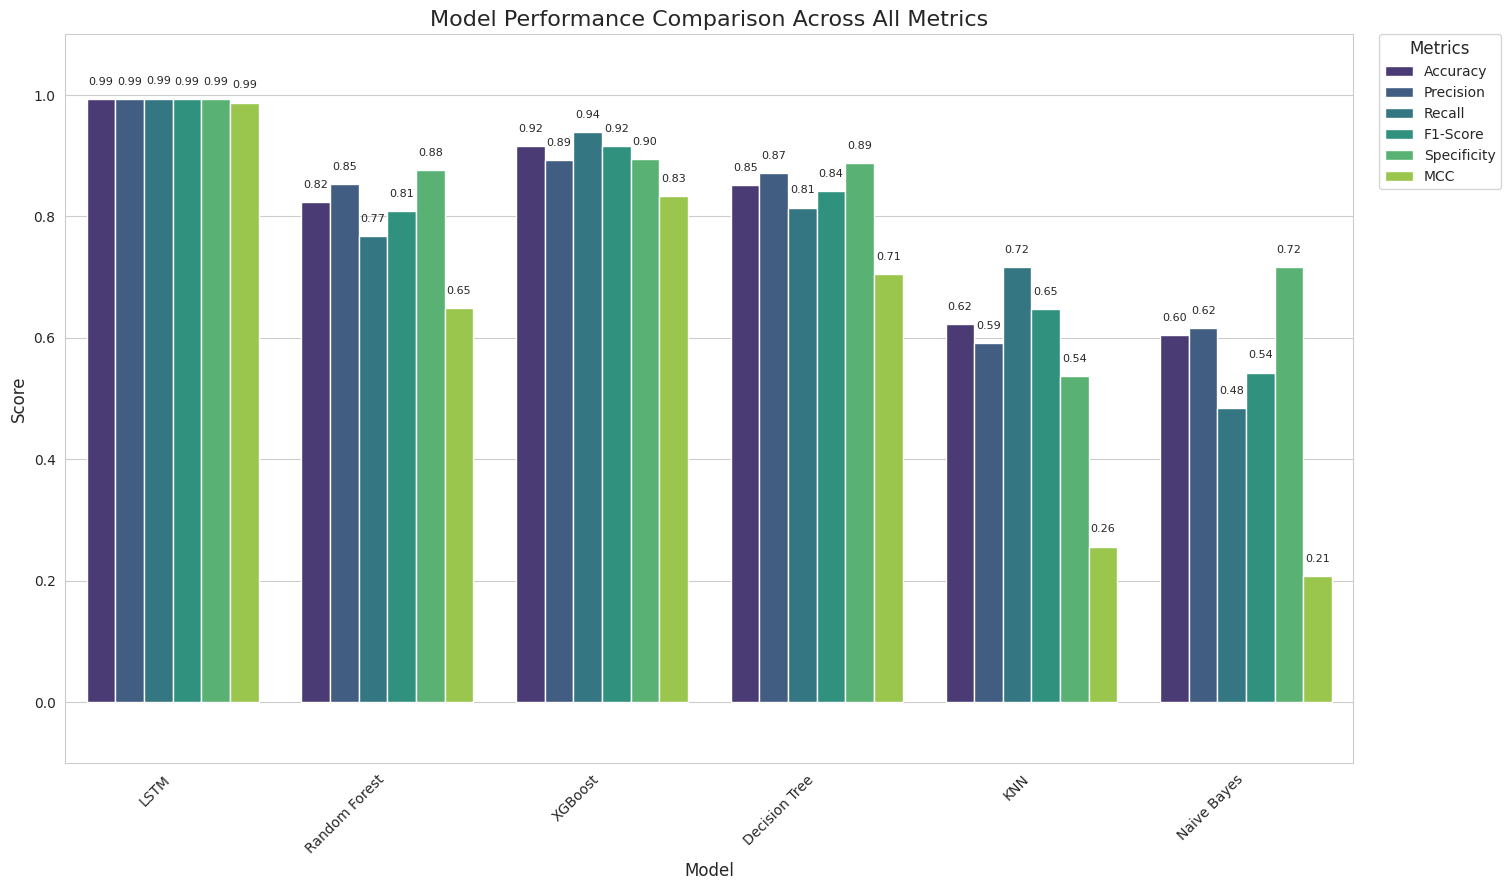

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to a long format for easier plotting
melted_all_metrics_df = all_metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Create the grouped bar chart
plt.figure(figsize=(16, 9)) # Adjust figure size for better readability with multiple bars
sns.barplot(x='Model', y='Score', hue='Metric', data=melted_all_metrics_df, palette='viridis')

# Set title and labels
plt.title('Model Performance Comparison Across All Metrics', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Adjust y-axis limits to accommodate MCC's range
plt.ylim(-0.1, 1.1) # MCC can be negative, so adjust lower bound

# Add a legend outside the plot area
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., title='Metrics', fontsize=10, title_fontsize=12)

# Add text labels on top of each bar
for container in plt.gca().containers:
    for bar in container:
        height = bar.get_height()
        plt.gca().text(bar.get_x() + bar.get_width() / 2,
                       height + 0.02, # Offset label slightly above the bar
                       f'{height:.2f}', # Format to two decimal places
                       ha='center', va='bottom', fontsize=8)

plt.tight_layout(rect=[0, 0, 0.95, 1]) # Adjust layout to make room for the legend
plt.show()